## An 1D example for demonstration

In [15]:
import torch
import gpytorch
from gpytorch.kernels import *
from torch.distributions.multivariate_normal import MultivariateNormal
import matplotlib.pyplot as plt
import viva
from viva import VIVACpp as VIVA, my_train_cpp as my_train
from data_gen import Normal_y_gen
from lagp.utils.gpytorch_utils import GPRegressionModel, AsymmetricLaplaceLikelihood, AsymmetricLaplaceLikelihood_DKLGP
plt.style.use('ggplot')
import statsmodels.api as sm

A function that generates training data randomly but testing data on a grid such that the prediction curve will appear continuous. 

In [2]:
def gen_data_mixed(nTrain, d, lengthscale=None, nugget4f=0.0, nugget4y=0.1,
                   nu=0.5,
                   seed=0, nTest=0, outputscale=1.0, y_gen=None):
    """
    Generate training data randomly and generate testing data on a grid
    """
    n = nTrain + nTest
    # Build locations (X)
    torch.manual_seed(seed)
    X_train = torch.rand(nTrain, d)
    nKnot = int(nTest ** (1 / d)) + 1
    edge = torch.linspace(0, 1, steps=nKnot)
    X_test = torch.flatten(
        torch.stack(torch.meshgrid([edge] * d, indexing='ij')),
        start_dim=1).t()[:nTest]
    X = torch.cat([X_train, X_test], dim=0)
    # Define a covariance kernel
    if lengthscale is None:
        lengthscale = torch.linspace(0.5, 2.5, d)
    logNugget4f = torch.log(torch.tensor(nugget4f))
    logNugget4y = torch.log(torch.tensor(nugget4y))
    K = ScaleKernel(MaternKernel(ard_num_dims=d, nu=nu))
    K.base_kernel.lengthscale = lengthscale
    K.outputscale = outputscale
    kernel4f = viva.Kernel(X, K, torch.exp(logNugget4f).item())
    # Build responses (y)
    covM4f = kernel4f(list(range(n)))
    GPObj4f = MultivariateNormal(torch.zeros(n), covM4f)
    f = GPObj4f.sample()
    if y_gen is None:
        y_gen = lambda x: x + \
                          torch.normal(torch.zeros(len(x)),
                                       nugget4y)
    y = y_gen(f)
    # y = y.sub(y.mean())
    return X, f, y, K, logNugget4f, logNugget4y

A function for plotting the true `f`, the observed responses `y`, and the predicted confidence intervals.

In [3]:
def my_plot(x, f, y, fhat, fhat_sd, fn):
    fig_size = (6, 5)
    marker_size = 2
    font_size = 24
    line_width = 2.0
    alpha = 0.3
    fig = plt.figure(figsize=fig_size)
    ax = fig.add_subplot(111)
    ax_objs = [ax.scatter(x, y, s=marker_size ** 2, alpha=alpha,
                          c='#d62728'),
               ax.plot(x, f, c='#1f77b4', linewidth=line_width)[0],
               ax.errorbar(x, fhat, 2.0 * fhat_sd, alpha=alpha, c='#ff7f0e')]
    ax.tick_params(axis='both', which='major', labelsize=font_size)
    ax.set_ylabel(None, fontsize=font_size)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.0f'))
    fig.set_tight_layout(True)
    fig_legend = plt.figure(figsize=(4 * 3, 1))
    legend_names = ["y", "f", "f | y"]
    fig_legend.legend(ax_objs, legend_names, 'lower center',
                      fontsize=font_size, ncol=len(legend_names))

Defining likelihood function and the generator for `y | f`.

In [4]:
y_gen = Normal_y_gen(0.3)
q = 0.9
likelihood = gpytorch.likelihoods.GaussianLikelihood()
likelihood = AsymmetricLaplaceLikelihood_DKLGP(quantile=q)
# likelihood.noise = 0.3 ** 2
classify = False  # Set to true if likelihood is logit (binary classification)

Generate data and kernel.

In [5]:
n_train = 132
n_test = 10
d = 1
rho = 2.0
X, f, y, K, logNugget4f, logNugget4y = \
    gen_data_mixed(n_train, d, nugget4f=0.0001, lengthscale=0.1,
                   y_gen=y_gen, nugget4y=0.1, nu=1.5, nTest=n_test)
X_train = X[:n_train]
X_test = X[n_train:]
f_test = f[n_train:]
y_train = y[:n_train]
y_test = y[n_train:]
mu_init = torch.zeros(y.shape)

In [13]:
X.size()

torch.Size([142, 1])

In [7]:
y.shape

torch.Size([142])

In [8]:
K.base_kernel.lengthscale

tensor([[0.1000]], grad_fn=<SoftplusBackward0>)

In [9]:
K

ScaleKernel(
  (base_kernel): MaternKernel(
    (raw_lengthscale_constraint): Positive()
  )
  (raw_outputscale_constraint): Positive()
)

Creat and train the VIVA model. A plot will be produced at the end.

In [16]:
# Load the dataset
mcycle = sm.datasets.get_rdataset("mcycle", "MASS")
df = mcycle.data
N = len(df)
# Check it out
print(df.shape)
X = df["times"]
y = df["accel"]

(133, 2)


In [20]:
X = torch.tensor(X).unsqueeze(-1)
y = torch.tensor(y)

C:\Users\JumpStart\AppData\Local\Temp\ipykernel_21988\3270478764.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X).unsqueeze(-1)
C:\Users\JumpStart\AppData\Local\Temp\ipykernel_21988\3270478764.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y)


In [21]:
model = VIVA(X, y, K, likelihood, rho, n_test=n_test,
                 classify=classify, use_ic0=False) # initialize from the laplace
my_train(model, n_Epoch=100)

mu_post, var_post = model.predict()
sd_post = var_post.sqrt()
mu_post_VIVA = mu_post.detach().clone()
sd_post_VIVA = sd_post.detach().clone()

tensor([[  55.1114],
        [  59.7040],
        [  73.4818],
        [  82.6671],
        [  91.8523],
        [ 142.3711],
        [ 151.5563],
        [ 156.1489],
        [ 179.1120],
        [ 188.2972],
        [ 202.0751],
        [ 202.0751],
        [ 220.4455],
        [ 229.6308],
        [ 234.2234],
        [ 243.4086],
        [ 252.5938],
        [ 261.7791],
        [ 303.1126],
        [ 312.2978],
        [ 316.8905],
        [ 335.2609],
        [ 335.2609],
        [ 335.2609],
        [ 335.2609],
        [ 335.2609],
        [ 335.2609],
        [ 339.8535],
        [ 353.6314],
        [ 353.6314],
        [ 353.6314],
        [ 353.6314],
        [ 358.2240],
        [ 358.2240],
        [ 362.8166],
        [ 362.8166],
        [ 367.4092],
        [ 367.4092],
        [ 372.0019],
        [ 372.0019],
        [ 372.0019],
        [ 376.5945],
        [ 376.5945],
        [ 381.1871],
        [ 385.7797],
        [ 385.7797],
        [ 385.7797],
        [ 404

RuntimeError: select(): index 553984 out of range for tensor of size [133, 1] at dimension 0
Exception raised from select_symint at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:1851 (most recent call first):
00007FFD77EE91D900007FFD77EE9130 c10.dll!c10::Error::Error [<unknown file> @ <unknown line number>]
00007FFD77E9501500007FFD77E94FA0 c10.dll!c10::IndexError::IndexError [<unknown file> @ <unknown line number>]
00007FFCED4AB3C000007FFCED4AA8B0 torch_cpu.dll!at::native::select_symint [<unknown file> @ <unknown line number>]
00007FFCEE12403100007FFCEE11B5F0 torch_cpu.dll!at::compositeexplicitautograd::view_copy_symint_outf [<unknown file> @ <unknown line number>]
00007FFCEE0EF04000007FFCEE0A63B0 torch_cpu.dll!at::compositeexplicitautograd::bucketize_outf [<unknown file> @ <unknown line number>]
00007FFCEDCADCD200007FFCEDC5A1D0 torch_cpu.dll!at::_ops::vsplit_int::redispatch [<unknown file> @ <unknown line number>]
00007FFCEDD76FB200007FFCEDD76F00

In [11]:
li = mu_post_VIVA - sd_post_VIVA
ui = mu_post_VIVA + sd_post_VIVA

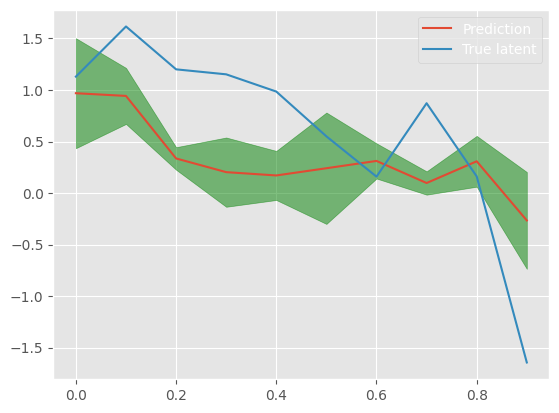

In [12]:
plt.plot(X_test, mu_post_VIVA, label = "Prediction")
plt.fill_between(x = X_test.squeeze(-1), y1=li, y2=ui, color = "green", alpha = 0.5)
#plt.scatter(X_test, y_test, label = "True")
plt.plot(X_test, f_test,label =  "True latent")
plt.legend()